<img src="./src/logo.png" width="250">

**Baustein:** Zeitreihenanalyse  $\rightarrow$ **Subbaustein:** Zeitreihen, CNNs
und XAI $\rightarrow$ **Begleitend zur Vorlesung**

**Version:** 1.0, **Lizenz:** <a rel="license" href="http://creativecommons.org/licenses/by-nc-nd/4.0/">CC BY-NC-ND 4.0</a>

***

# Zeitreihenanalyse: Zeitreihen und CNNs

In [7]:
from pandas import read_csv
import pandas as pd
from sklearn.impute import KNNImputer
from src.plot_preprocessing import plot_imputation

In [8]:
SIGNALS = ["acc_x", "acc_y", "acc_z"]

SAMPLING_RATE = 50  # Datenpunkte pro Sekunde / Hz
WINDOW_SIZE = 2.56  # Fenstergröße in Sekunden
OVERLAP = 0.5  # Überlappung
N_SAMPLES = int(WINDOW_SIZE * SAMPLING_RATE)  # Anzahl der Samples pro Fenster
STEP_SIZE = int(N_SAMPLES * (1 - OVERLAP))  # Schrittgröße für das Fenster

In [9]:
# Pfad zur CSV-Datei
data_acc_orig = read_csv('./data/Accelerometer_orig.csv', sep=',', header=0)#, usecols=[0,1])
data_acc_prepro = read_csv('./data/Accelerometer_missing.csv', sep=',', header=0)#, usecols=[0,1])

In [10]:
pd.isna(data_acc_prepro['Acceleration x (m/s^2)']).values.any()

True

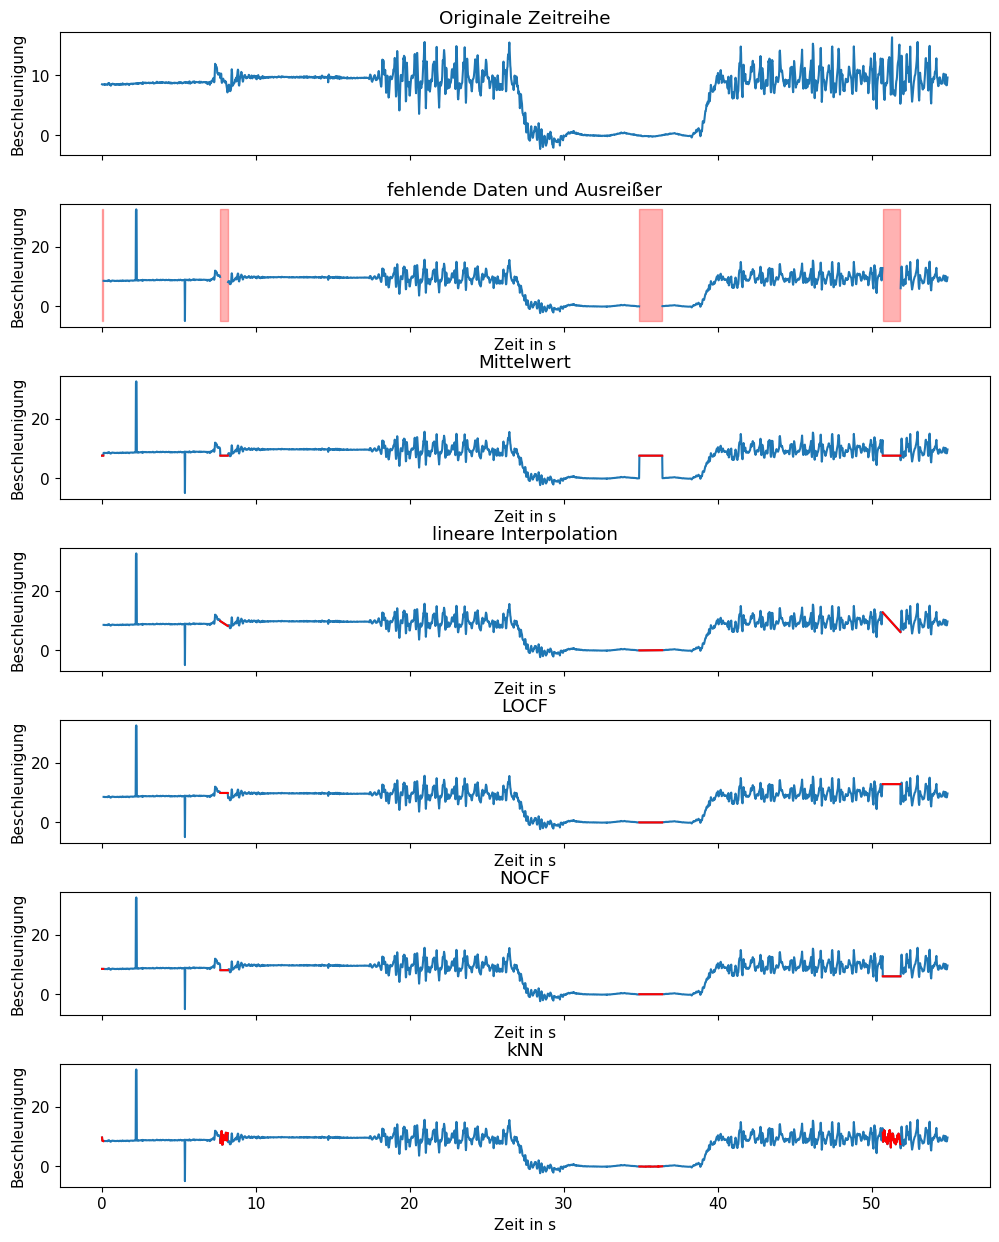

In [11]:
data_acc_prepro['Mittelwert'] = data_acc_prepro['Acceleration x (m/s^2)'].fillna(data_acc_prepro['Acceleration x (m/s^2)'].mean())
data_acc_prepro['lineare Interpolation'] = data_acc_prepro['Acceleration x (m/s^2)'].interpolate(method='linear')
data_acc_prepro['LOCF'] = data_acc_prepro['Acceleration x (m/s^2)'].ffill()
data_acc_prepro['NOCF'] = data_acc_prepro['Acceleration x (m/s^2)'].bfill()
impu = KNNImputer(n_neighbors=3)
data_acc_prepro['kNN'] = impu.fit_transform(data_acc_prepro.iloc[:,1:4])[:,0]
plot_imputation(data_acc_orig, data_acc_prepro,col='Acceleration x (m/s^2)',start_time=0, end_time=55, path='./data/imputation_kNN.pdf')

In [6]:
exec(open('src/vorverarbeitung_zeitreihe.py').read())

Output()

---

<a rel="license" href="http://creativecommons.org/licenses/by-nc-nd/4.0/"><img alt="Creative Commons Lizenzvertrag" style="border-width:0" src="https://i.creativecommons.org/l/by-nc-nd/4.0/88x31.png" /></a><br /><span xmlns:dct="http://purl.org/dc/terms/" property="dct:title">Die Übungsserie begleitend zum AI4ALL-Kurs</span> der <span xmlns:cc="http://creativecommons.org/ns#" property="cc:attributionName">EAH Jena</span> ist lizenziert unter einer <a rel="license" href="http://creativecommons.org/licenses/by-nc-nd/4.0/">Creative Commons Namensnennung - Nicht kommerziell - Keine Bearbeitungen 4.0 International Lizenz</a>.

Der AI4ALL-Kurs entsteht im Rahmen des Projekts MoVeKI2EAH. Das Projekt MoVeKI2EAH wird durch das BMBF (Bundesministerium für Bildung und Forschung) und den Freistaat Thüringen im Rahmen der Bund-Länder-Initiative zur Förderung von Künstlicher Intelligenz in der Hochschulbildung gefördert (12/2021 bis 11/2025, Föderkennzeichen 16DHBKI081).